# Day 54 — LLM Evaluation
### LLM-as-judge, hallucination detection, faithfulness vs relevancy scoring

## 1. Setup

In [1]:
import anthropic
import json

client = anthropic.Anthropic()
MODEL = "claude-haiku-4-5"

def ask(prompt, system=None, max_tokens=500):
    kwargs = {
        "model": MODEL,
        "max_tokens": max_tokens,
        "messages": [{"role": "user", "content": prompt}]
    }
    if system:
        kwargs["system"] = system
    response = client.messages.create(**kwargs)
    return response.content[0].text

print("Client ready, model:", MODEL)

Client ready, model: claude-haiku-4-5


## 2. Our Test Dataset — Questions, Contexts, and Answers

In [2]:
eval_dataset = [
    {
        "question": "What is the capital of France?",
        "context": "France is a country in Western Europe. Its capital city is Paris, which is also the largest city in the country. Paris is known for the Eiffel Tower and the Louvre museum.",
        "answer_good": "The capital of France is Paris.",
        "answer_bad": "The capital of France is Lyon, which is the second largest city.",
        "answer_hallucinated": "The capital of France is Paris. It has a population of 50 million people and was founded in 1200 AD."
    },
    {
        "question": "What does photosynthesis produce?",
        "context": "Photosynthesis is a process used by plants to convert light energy into chemical energy. During this process, plants absorb carbon dioxide and water, and produce glucose and oxygen as outputs.",
        "context": "Photosynthesis is a process used by plants to convert light energy into chemical energy. During this process, plants absorb carbon dioxide and water, and produce glucose and oxygen as outputs.",
        "answer_good": "Photosynthesis produces glucose and oxygen.",
        "answer_bad": "Photosynthesis produces carbon dioxide and water.",
        "answer_hallucinated": "Photosynthesis produces glucose, oxygen, and nitrogen gas, which plants release into the atmosphere."
    },
    {
        "question": "Who wrote Romeo and Juliet?",
        "context": "Romeo and Juliet is a tragedy written by William Shakespeare, believed to have been written between 1594 and 1596. It is one of his most performed plays worldwide.",
        "answer_good": "Romeo and Juliet was written by William Shakespeare.",
        "answer_bad": "Romeo and Juliet was written by Charles Dickens.",
        "answer_hallucinated": "Romeo and Juliet was written by William Shakespeare in 1589, during his time living in Verona, Italy."
    }
]

print(f"Dataset: {len(eval_dataset)} examples")
print(f"Each example has: question, context, answer_good, answer_bad, answer_hallucinated")

Dataset: 3 examples
Each example has: question, context, answer_good, answer_bad, answer_hallucinated


## 3. LLM-as-Judge — Faithfulness Scoring

In [3]:
def score_faithfulness(question, context, answer):
    prompt = f"""You are an expert evaluator. Score the faithfulness of the answer to the context.

Faithfulness measures whether the answer contains ONLY information supported by the context.
An answer is unfaithful if it introduces facts not present in the context.

Question: {question}
Context: {context}
Answer: {answer}

Respond with ONLY a JSON object like this:
{{"score": 0.0, "reason": "brief explanation"}}

Score 1.0 = fully faithful (every claim is supported by context)
Score 0.5 = partially faithful (some claims supported, some not)
Score 0.0 = unfaithful (answer contradicts or adds to context)"""

    result = ask(prompt, max_tokens=200)
    try:
        result = result.strip()
        if result.startswith("```"):
            result = result.split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        return json.loads(result.strip())
    except:
        return {"score": -1, "reason": "parse error"}

# test on one example
ex = eval_dataset[0]
print("GOOD answer:")
print(score_faithfulness(ex["question"], ex["context"], ex["answer_good"]))
print("\nHALLUCINATED answer:")
print(score_faithfulness(ex["question"], ex["context"], ex["answer_hallucinated"]))

GOOD answer:
{'score': 1.0, 'reason': 'The answer correctly states that Paris is the capital of France, which is directly supported by the context. No unsupported claims are introduced.'}

HALLUCINATED answer:
{'score': 0.5, 'reason': 'The answer correctly states that Paris is the capital of France, which is supported by the context. However, the claims about Paris having a population of 50 million people and being founded in 1200 AD are not mentioned in the provided context and therefore cannot be verified as faithful to it.'}


## 4. LLM-as-Judge — Relevancy Scoring

In [4]:
def score_relevancy(question, answer):
    prompt = f"""You are an expert evaluator. Score how relevant the answer is to the question.

Relevancy measures whether the answer actually addresses what was asked.
An irrelevant answer may be factually correct but not answer the question.

Question: {question}
Answer: {answer}

Respond with ONLY a JSON object like this:
{{"score": 0.0, "reason": "brief explanation"}}

Score 1.0 = fully relevant (directly answers the question)
Score 0.5 = partially relevant (addresses question but includes unnecessary info)
Score 0.0 = not relevant (does not answer the question at all)"""

    result = ask(prompt, max_tokens=200)
    try:
        result = result.strip()
        if result.startswith("```"):
            result = result.split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        return json.loads(result.strip())
    except:
        return {"score": -1, "reason": "parse error"}

ex = eval_dataset[1]
print("GOOD answer:")
print(score_relevancy(ex["question"], ex["answer_good"]))
print("\nBAD answer:")
print(score_relevancy(ex["question"], ex["answer_bad"]))

GOOD answer:
{'score': 1.0, 'reason': 'The answer directly and completely addresses the question by identifying the two main products of photosynthesis: glucose and oxygen.'}

BAD answer:
{'score': 0.0, 'reason': 'The answer is factually incorrect and irrelevant. Photosynthesis produces glucose (sugar) and oxygen, not carbon dioxide and water. Carbon dioxide and water are actually the inputs (reactants) of photosynthesis, not the products.'}


## 5. LLM-as-Judge — Correctness Scoring

In [5]:
def score_correctness(question, answer, ground_truth):
    prompt = f"""You are an expert evaluator. Score the factual correctness of the answer.

Question: {question}
Ground truth answer: {ground_truth}
Answer to evaluate: {answer}

Respond with ONLY a JSON object like this:
{{"score": 0.0, "reason": "brief explanation"}}

Score 1.0 = fully correct (matches ground truth)
Score 0.5 = partially correct (some correct elements, some wrong)
Score 0.0 = incorrect (contradicts ground truth)"""

    result = ask(prompt, max_tokens=200)
    try:
        result = result.strip()
        if result.startswith("```"):
            result = result.split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        return json.loads(result.strip())
    except:
        return {"score": -1, "reason": "parse error"}

ex = eval_dataset[2]
print("GOOD answer:")
print(score_correctness(ex["question"], ex["answer_good"], ex["answer_good"]))
print("\nBAD answer:")
print(score_correctness(ex["question"], ex["answer_bad"], ex["answer_good"]))
print("\nHALLUCINATED answer:")
print(score_correctness(ex["question"], ex["answer_hallucinated"], ex["answer_good"]))

GOOD answer:
{'score': 1.0, 'reason': 'The answer exactly matches the ground truth. Romeo and Juliet was indeed written by William Shakespeare.'}

BAD answer:
{'score': 0.0, 'reason': 'The answer is completely incorrect. Romeo and Juliet was written by William Shakespeare, not Charles Dickens. Charles Dickens was a 19th-century novelist who wrote works like A Tale of Two Cities and Oliver Twist, but he did not write Romeo and Juliet.'}

HALLUCINATED answer:
{'score': 0.5, 'reason': 'The answer correctly identifies William Shakespeare as the author, but contains factual errors: the play was likely written between 1594-1596 (not 1589), and Shakespeare wrote it in England, not while living in Verona, Italy. The core fact is correct but additional details are incorrect.'}


## 6. Full Evaluation Pipeline — Batch Scoring

In [6]:
import pandas as pd

results = []

for ex in eval_dataset:
    for answer_type in ["answer_good", "answer_bad", "answer_hallucinated"]:
        answer = ex[answer_type]

        faithfulness = score_faithfulness(ex["question"], ex["context"], answer)
        relevancy = score_relevancy(ex["question"], answer)
        correctness = score_correctness(ex["question"], answer, ex["answer_good"])

        results.append({
            "question": ex["question"][:40] + "...",
            "answer_type": answer_type.replace("answer_", ""),
            "faithfulness": faithfulness["score"],
            "relevancy": relevancy["score"],
            "correctness": correctness["score"],
            "composite": round((faithfulness["score"] + relevancy["score"] + correctness["score"]) / 3, 2)
        })

results_df = pd.DataFrame(results)
results_df

,question,answer_type,faithfulness,relevancy,correctness,composite
0,What is the capital of France?...,good,1.0,1.00,1.0,1.00
1,What is the capital of France?...,bad,0.0,0.00,0.0,0.00
2,What is the capital of France?...,hallucinated,0.5,1.00,0.5,0.67
3,What does photosynthesis produce?...,good,1.0,1.00,1.0,1.00
4,What does photosynthesis produce?...,bad,0.0,0.00,0.0,0.00
5,What does photosynthesis produce?...,hallucinated,0.5,0.75,0.5,0.58
6,Who wrote Romeo and Juliet?...,good,1.0,1.00,1.0,1.00
7,Who wrote Romeo and Juliet?...,bad,0.0,0.00,0.0,0.00
8,Who wrote Romeo and Juliet?...,hallucinated,0.5,0.75,0.5,0.58


## 7. Visualise the Results

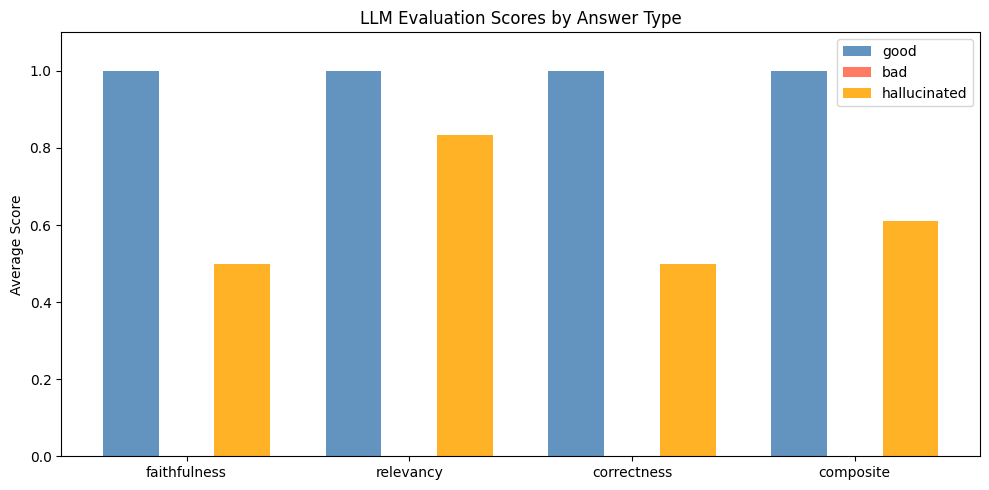

In [7]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["faithfulness", "relevancy", "correctness", "composite"]
answer_types = ["good", "bad", "hallucinated"]
colors = ["steelblue", "tomato", "orange"]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (atype, color) in enumerate(zip(answer_types, colors)):
    subset = results_df[results_df["answer_type"] == atype]
    means = [subset[m].mean() for m in metrics]
    ax.bar(x + i * width, means, width, label=atype, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Average Score")
ax.set_title("LLM Evaluation Scores by Answer Type")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Key Findings

| Answer Type | Faithfulness | Relevancy | Correctness | Composite |
|-------------|-------------|-----------|-------------|-----------|
| Good        | 1.00        | 1.00      | 1.00        | 1.00      |
| Bad         | 0.00        | 0.00      | 0.00        | 0.00      |
| Hallucinated| 0.50        | 0.83      | 0.50        | 0.61      |

**Why hallucinations are dangerous:**
Hallucinated answers score 0.83 on relevancy — they directly address the question
and sound plausible. Simple "does it answer the question?" checks would pass them.
Only faithfulness catches the fabricated facts by comparing against the source context.

**The RAGAS insight:**
No single metric is enough. A production RAG system needs all three:
- Faithfulness: catches hallucinations (invented facts)
- Relevancy: catches irrelevant or off-topic answers
- Correctness: catches factually wrong answers

**Composite score threshold:**
In production, a composite score below 0.7 typically flags an answer for human review.